---
# Cairo University Faculty of Engineering
## Machine Learning
## Assignment 1

---

Please write your full name here
- **Name** : Raghad Abdelhameed

**Instructions**
1. Submit the notebook **with all cell outputs visible**. Use 'Restart & Run All' before saving to ensure your code is functional.
2. For Google Collaboratory  notebooks, you must **set permissions to 'Anyone with the link can edit'**. Locked notebooks will be considered late.
3. **(1 scale) deduction per day**. Any delay (even 1 minute) counts as a full day. <u>No submissions accepted after 48 hours</u>.
4. **5 students will be randomly selected** per assignment for an in-person discussion during the designated tutorial slot. Your grade will depend on your ability to explain your logic. <u>Failure to demonstrate understanding can result in a zero</u>, regardless of the notebook's quality.
5. <u>A student can be chosen once or more</u> for the in-person assignment discussion during the semester. **<u>A student that gets selected twice and is absent on both occasions will receive a zero for that assignment</u>**.

## Introduction to Machine Learning
For this assignment, you will be using the Breast Cancer Wisconsin (Diagnostic) Database to create a classifier that can help diagnose patients. First, read through the description of the dataset (below).

In [154]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

cancer = load_breast_cancer()

print(cancer.DESCR) # Print the data set description

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

The object returned by `load_breast_cancer()` is a scikit-learn Bunch object, which is similar to a dictionary.

In [155]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

### Question 0

How many features does the breast cancer dataset have?

*This function should return an integer.*

In [156]:
def answer_zero():
   cancer = load_breast_cancer()
   return cancer.data.shape[1]  # Return your answer

In [157]:
print(answer_zero())

30


### Question 1
Pandas dataframes are much easier and more interpretable when dealing with tables. **Convert the cancer data into dataframe.**

Note: Scikit-learn works with lists, numpy arrays, scipy-sparse matrices, and pandas DataFrames, so converting the dataset to a DataFrame is not necessary for training any model.

*This function should return a (569, 31) DataFrame with *

*columns = *

    ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
    'mean smoothness', 'mean compactness', 'mean concavity',
    'mean concave points', 'mean symmetry', 'mean fractal dimension',
    'radius error', 'texture error', 'perimeter error', 'area error',
    'smoothness error', 'compactness error', 'concavity error',
    'concave points error', 'symmetry error', 'fractal dimension error',
    'worst radius', 'worst texture', 'worst perimeter', 'worst area',
    'worst smoothness', 'worst compactness', 'worst concavity',
    'worst concave points', 'worst symmetry', 'worst fractal dimension',
    'target']
    
*and index = *

RangeIndex(start=0, stop=569, step=1)

In [158]:
def answer_one():

    # Your code here
    # Create dataframe with feature names as columns
    df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

    # Add target column
    df['target'] = cancer.target

    return df  # Return your answer

print(answer_one().head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

### Question 2
What is the class distribution? (i.e. how many instances of `malignant` and how many `benign`?)

In [159]:
def answer_two():
    cancerdf = answer_one()

    # Your code here
    malignant = cancerdf[cancerdf['target'] == 0].shape[0]
    benign = cancerdf[cancerdf['target'] == 1].shape[0]

    # Return as a Series with index 'malignant' and 'benign'
    return pd.Series([malignant, benign], index=['malignant', 'benign'])

print(answer_two())

malignant    212
benign       357
dtype: int64


### Question 3
Split the DataFrame into `X` (the data) and `y` (the labels).

In [160]:
def answer_three():
    cancerdf = answer_one()

    # Your code here
    X = cancerdf.drop('target', axis=1)
    y = cancerdf['target']

    return X, y

### Question 4
Using `train_test_split`, split `X` and `y` into training and test sets. Use only 20% of the data for testing. Use a random state of 40

In [161]:
from sklearn.model_selection import train_test_split

def answer_four():
    X, y = answer_three()

    # Your code here
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = answer_four()
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 455
Test set size: 114


In [162]:
X_train, X_test, y_train, y_test = answer_four()
print(len(X_train))

455


### Question 5
Fit a Support Vector Machine classifier (SVC) with `X_train`, `y_train`.

In [163]:
from sklearn.svm import SVC

def answer_five():
    X_train, X_test, y_train, y_test = answer_four()
    svc = SVC(kernel='rbf', C=1.0, random_state=40)
    svc.fit(X_train, y_train)
    return svc

In [164]:
print(answer_five())

SVC(random_state=40)


### Question 6
- Create an example that consists of the mean values for each feature in the X_train data.
- Using your SVC classifier, predict the class label for this example.

In [165]:
def answer_six():
    # Your code here
    X_train, X_test, y_train, y_test = answer_four()
    svc = answer_five()

    # Calculate mean values for each feature in X_train
    example = X_train.mean().values.reshape(1, -1)

    # Predict class label
    prediction = svc.predict(example)

    return prediction[0]  # Return your answer --> label prediction

print(f"Predicted class: {answer_six()}")

Predicted class: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [166]:
print(answer_six())

1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


### Question 7
Using your SVC classifier, predict the class labels for the test set `X_test`. Return the predicted labels

In [167]:
def answer_seven():
    X_train, X_test, y_train, y_test = answer_four()
    svc = answer_five()

    # Your code here
    y_pred = svc.predict(X_test)

    return y_pred  # Return your answer

print(f"First 10 predictions: {answer_seven()[:10]}")

First 10 predictions: [1 0 1 1 0 1 1 1 0 1]


In [168]:
print(answer_seven())

[1 0 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 0 0 1 1 1 0 0 1 1 1 1
 0 1 1 0 1 1 1 0 1 1 1 0 1 0 1 1 1 0 1 0 1 0 1 1 1 1 1 1 0 0 0 1 1 1 1 0 1
 0 0 0 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1
 1 0 1]


### Question 8
Find the score (accuracy) of your SVC classifier using `X_test` and `y_test` & `X_train` and `y_train`.
1. Is the training accuracy higher or lower that the testing accuracy?
2. According to the test accuracy, would this model generalize well to new unseen inputs?

In [169]:
def answer_eight():
    X_train, X_test, y_train, y_test = answer_four()
    svc = answer_five()

    # Your code here
    train_score = svc.score(X_train, y_train)
    test_score = svc.score(X_test, y_test)

    return (test_score, train_score)  # Return your answer --> (test_score, train_score)

test_score, train_score = answer_eight()
print(f"Test accuracy: {test_score:.4f}")
print(f"Train accuracy: {train_score:.4f}")

Test accuracy: 0.9298
Train accuracy: 0.9187


In [170]:
print(answer_eight())

(0.9298245614035088, 0.9186813186813186)


**Answer**

1. The training accuracy (91.87%) is a bit lower than the testing accuracy (92.98%).

2. According to the test accuracy of ~92.98%, this model would generalize well to new unseen inputs. The small gap between training and testing accuracy (about 1%) indicates that the model is not significantly overfitting and should perform well on new data.

### Question 9
##### Accuracy Plot
* Create `mal_train_X`, `mal_train_y`,`ben_train_X`,`ben_train_y`, `mal_test_X`,`mal_test_y`, `ben_test_X` and `ben_test_y` portions of the dataset. Where `mal_train_X` contains all training samples that belongs to malignant class while `mal_train_y` contains all labels of the samples that belongs to malignant class, and so on for other variables.

* Calculate Accuracy scores for each case and save all the results in a list called `scores` using svc model from question 5.

Try using the plotting function below to visualize the differet predicition scores between training and test sets, as well as malignant and benign cells.

Malignant Training Accuracy: 0.8150
Benign Training Accuracy: 0.9823
Malignant Test Accuracy: 0.8718
Benign Test Accuracy: 0.9600


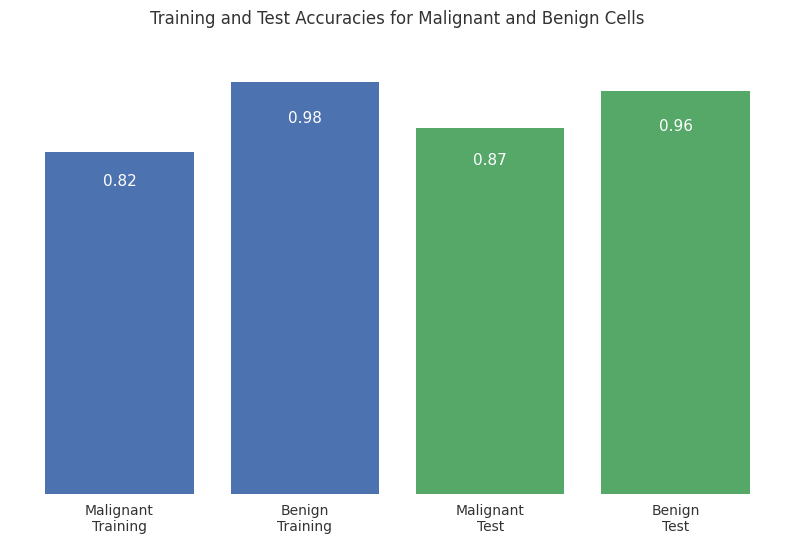

In [171]:
def accuracy_plot():
    import matplotlib.pyplot as plt

    %matplotlib inline

    X_train, X_test, y_train, y_test = answer_four()

    # Find the training and testing accuracies by target value (i.e. malignant, benign)

    # #################################################################################
    # ###################### Write your code here #####################################
    # #################################################################################

    # Create masks for malignant (0) and benign (1)
    mal_train_mask = (y_train == 0)
    ben_train_mask = (y_train == 1)
    mal_test_mask = (y_test == 0)
    ben_test_mask = (y_test == 1)

    # Split the data
    mal_train_X = X_train[mal_train_mask]
    mal_train_y = y_train[mal_train_mask]
    ben_train_X = X_train[ben_train_mask]
    ben_train_y = y_train[ben_train_mask]

    mal_test_X = X_test[mal_test_mask]
    mal_test_y = y_test[mal_test_mask]
    ben_test_X = X_test[ben_test_mask]
    ben_test_y = y_test[ben_test_mask]

    svc = answer_five()

    # Calculate accuracy scores for each subset
    mal_train_score = svc.score(mal_train_X, mal_train_y)
    ben_train_score = svc.score(ben_train_X, ben_train_y)
    mal_test_score = svc.score(mal_test_X, mal_test_y)
    ben_test_score = svc.score(ben_test_X, ben_test_y)

    scores = [mal_train_score, ben_train_score, mal_test_score, ben_test_score]

    # Print the scores
    print(f"Malignant Training Accuracy: {mal_train_score:.4f}")
    print(f"Benign Training Accuracy: {ben_train_score:.4f}")
    print(f"Malignant Test Accuracy: {mal_test_score:.4f}")
    print(f"Benign Test Accuracy: {ben_test_score:.4f}")

    plt.figure(figsize=(10, 6))

    # Plot the scores as a bar chart
    bars = plt.bar(np.arange(4), scores, color=['#4c72b0','#4c72b0','#55a868','#55a868'])

    # directly label the score onto the bars
    for bar in bars:
        height = bar.get_height()
        plt.gca().text(bar.get_x() + bar.get_width()/2, height*.90, '{0:.{1}f}'.format(height, 2),
                     ha='center', color='w', fontsize=11)

    # remove all the ticks (both axes), and tick labels on the Y axis
    plt.tick_params(top=False, bottom=False, left=False, right=False, labelleft=False, labelbottom=True)

    # remove the frame of the chart
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    plt.xticks([0,1,2,3], ['Malignant\nTraining', 'Benign\nTraining', 'Malignant\nTest', 'Benign\nTest'], alpha=0.8)
    plt.title('Training and Test Accuracies for Malignant and Benign Cells', alpha=0.8)
    plt.ylim(0, 1.1)
    plt.show()

accuracy_plot()

Malignant Training Accuracy: 0.8150
Benign Training Accuracy: 0.9823
Malignant Test Accuracy: 0.8718
Benign Test Accuracy: 0.9600


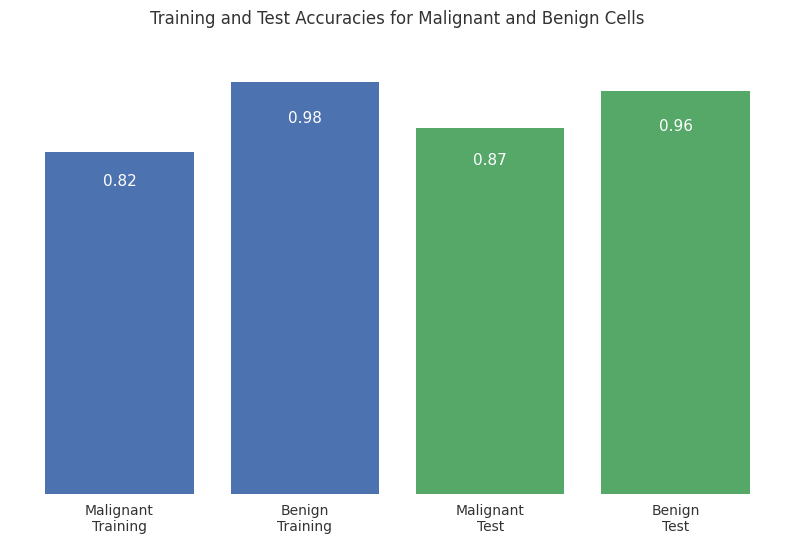

In [172]:
accuracy_plot()

### Question 10
1. Load Iris dataset from sklearn.
2. Split the data into training and testing (30% testing), use random_state 100
3. Create a scatter plot matrix similar to the one created in tutorial.
4. Choose two features only to train a svc model (Choose best two features through observing the scatter plot).
5. Evaluate your model performance and comment on your results.
    - Print testing and training accuracies
    - The confusion matrix helps assess classification model performance in machine learning by comparing predicted values against actual values for a dataset [Link](https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/). Draw the confusion matrix for the true and predicted test data.

    - **Questions to answer**:
        - Do you think the model did well?
        - Suggest one way to improve the model results

In [173]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names
print(f"Feature names: {feature_names}")
print(f"Target names: {target_names}")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [174]:
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = y
iris_df['species_name'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("\nFirst 5 rows of Iris dataset:")
print(iris_df.head())


First 5 rows of Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


In [175]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (105, 4)
Test set size: (45, 4)


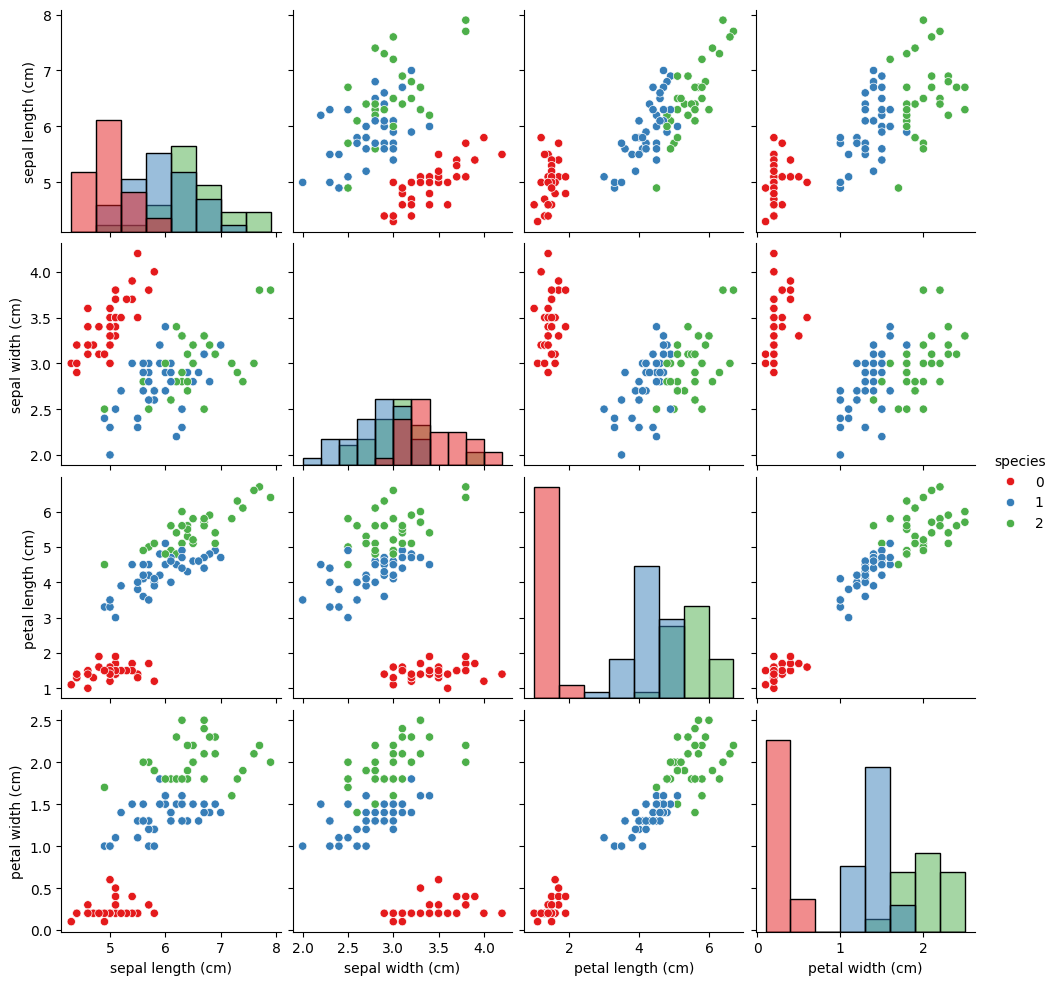

In [176]:
X_train_df = pd.DataFrame(X_train, columns=feature_names)
train_df = pd.concat([X_train_df, pd.Series(y_train, name='species', index=X_train_df.index)], axis=1)

sns.pairplot(
    train_df,
    hue='species',
    palette='Set1',
    diag_kind='hist'
)
plt.show()

In [177]:
# Select the two best features based on pair plot observation: petal length and petal width
selected_features = ['petal length (cm)', 'petal width (cm)']

In [178]:
# Get the indices of the selected features
feature_indices = [feature_names.index(f) for f in selected_features]

X_train_selected = X_train[:, feature_indices]
X_test_selected = X_test[:, feature_indices]

In [179]:

# Train an SVC model with the selected features
svc_iris = SVC(random_state=100)
svc_iris.fit(X_train_selected, y_train)


SVC(random_state=100)

In [180]:
# Predict on training and test sets
y_train_pred = svc_iris.predict(X_train_selected)
y_test_pred = svc_iris.predict(X_test_selected)

In [181]:
# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9524
Testing Accuracy: 0.9556


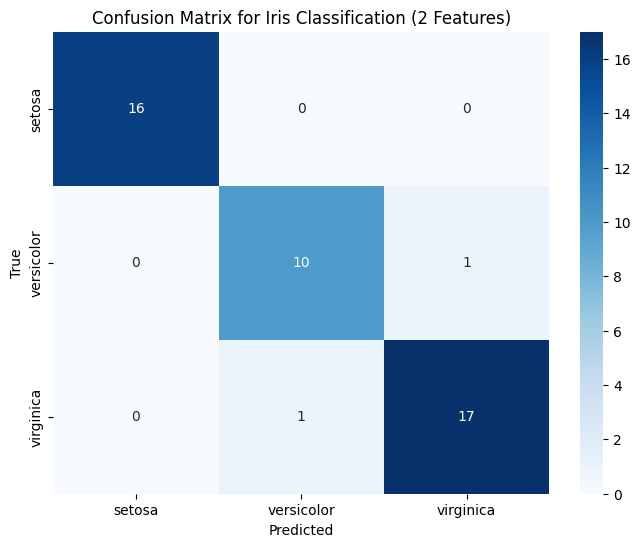

In [182]:
# Draw the confusion matrix for the true and predicted test data
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Iris Classification (2 Features)')
plt.show()

**Answer**

1. Yes, the model did well (test accuracy = 95.56% and train accuracy = 95.24%), there is no overfitting.

2. One effective way to improve the model would be to perform hyperparameter tuning using GridSearchCV. The default SVC parameters SVC(random_state=100) may not be optimal for this specific dataset. By systematically searching for the best combination of parameters, we could potentially achieve 100% accuracy.